In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import os

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

pd.set_option("display.width", 120)
print("Libraries loaded ✅")

Libraries loaded ✅


In [4]:
df = pd.read_csv("yaleemmlc_admissionprediction_triage.csv")
print("Loaded", df.shape[0], "patients and", df.shape[1], "columns.")
df.head()

Loaded 16965 patients and 226 columns.


,Unnamed: 0,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,...,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
0,7,A,4.0,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,17,B,2.0,53.0,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,40,A,2.0,49.0,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,47,A,3.0,22.0,Female,Hispanic or Latino,White or Caucasian,English,Catholic,Single,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,60,A,2.0,62.0,Male,Non-Hispanic,White or Caucasian,English,Protestant,Divorced,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
TARGET = "esi"

VITALS = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp", "triage_vital_rr",
          "triage_vital_o2", "triage_vital_temp", "triage_glucose"]
DEMOGRAPHICS = ["age", "gender", "ethnicity", "race", "lang", "religion",
                "maritalstatus", "employstatus", "insurance_status"]
ADMIN = ["dep_name", "arrivalmode", "arrivalmonth", "arrivalday", "arrivalhour_bin"]
LEAKAGE = ["disposition", "previousdispo"]

FEATURES = [c for c in df.columns if c != TARGET and c not in LEAKAGE + ADMIN + DEMOGRAPHICS]

X = df[FEATURES]
y = df[TARGET]

print("Model will use", len(FEATURES), "features to predict:", TARGET)

Model will use 209 features to predict: esi


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
print("Training patients:", X_train.shape[0])
print("Testing patients: ", X_test.shape[0])

Training patients: 13572
Testing patients:  3393


In [7]:
# --- Dummy baseline ---
dummy = DummyClassifier(strategy="stratified", random_state=42)
dummy.fit(X_train, y_train)
pred_dummy = dummy.predict(X_test)

# --- Logistic Regression (impute + scale) ---
imputer = SimpleImputer(strategy="median")
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

start = time.perf_counter()
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)
logreg_train_time = time.perf_counter() - start

start = time.perf_counter()
pred_logreg = logreg.predict(X_test_scaled)
logreg_infer_time = ((time.perf_counter() - start) / len(X_test)) * 1000  # ms per patient

# --- Decision Tree ---
start = time.perf_counter()
tree = DecisionTreeClassifier(max_depth=5, random_state=42)
tree.fit(X_train, y_train)
tree_train_time = time.perf_counter() - start

start = time.perf_counter()
pred_tree = tree.predict(X_test)
tree_infer_time = ((time.perf_counter() - start) / len(X_test)) * 1000

print("Week 6 baselines rebuilt ✅")
print(f"Logistic Regression — train: {logreg_train_time:.3f}s, inference: {logreg_infer_time:.4f} ms/patient")
print(f"Decision Tree       — train: {tree_train_time:.3f}s, inference: {tree_infer_time:.4f} ms/patient")

Week 6 baselines rebuilt ✅
Logistic Regression — train: 11.178s, inference: 0.0035 ms/patient
Decision Tree       — train: 0.259s, inference: 0.0029 ms/patient


In [8]:
start = time.perf_counter()
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_train_time = time.perf_counter() - start

start = time.perf_counter()
pred_rf = rf.predict(X_test)
rf_infer_time = ((time.perf_counter() - start) / len(X_test)) * 1000

print(f"Random Forest trained in {rf_train_time:.3f} seconds")
print(f"Average inference: {rf_infer_time:.4f} ms per patient")

Random Forest trained in 4.962 seconds
Average inference: 0.1010 ms per patient


In [9]:
print("===== Random Forest =====")
print(classification_report(y_test, pred_rf, digits=3, zero_division=0))

rf_accuracy = accuracy_score(y_test, pred_rf)
rf_macro_f1 = f1_score(y_test, pred_rf, average="macro")
rf_weighted_f1 = f1_score(y_test, pred_rf, average="weighted")
rf_esi1_recall = recall_score(y_test, pred_rf, labels=[1], average=None, zero_division=0)[0]

print(f"\nAccuracy: {rf_accuracy:.3f}")
print(f"Macro F1: {rf_macro_f1:.3f}")
print(f"Weighted F1: {rf_weighted_f1:.3f}")
print(f"Recall (ESI 1): {rf_esi1_recall:.3f}")

===== Random Forest =====
              precision    recall  f1-score   support

         1.0      0.000     0.000     0.000         5
         2.0      0.786     0.402     0.532      1097
         3.0      0.547     0.931     0.689      1663
         4.0      0.333     0.002     0.004       556
         5.0      0.000     0.000     0.000        72

    accuracy                          0.587      3393
   macro avg      0.333     0.267     0.245      3393
weighted avg      0.577     0.587     0.510      3393


Accuracy: 0.587
Macro F1: 0.245
Weighted F1: 0.510
Recall (ESI 1): 0.000


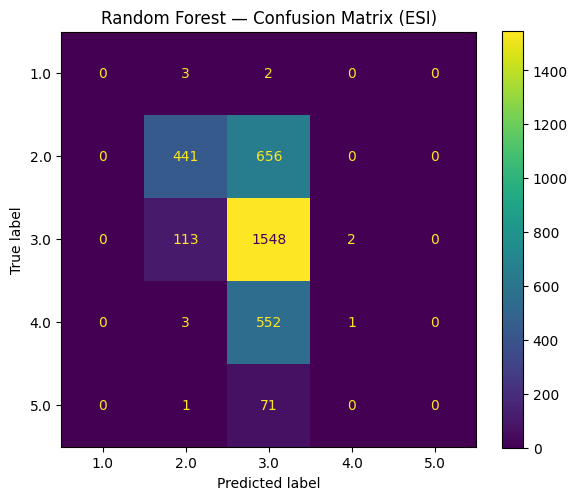

In [10]:
os.makedirs("docs", exist_ok=True)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, pred_rf, ax=ax)
ax.set_title("Random Forest — Confusion Matrix (ESI)")
plt.tight_layout()
plt.savefig("docs/confusion_matrix_rf.png", dpi=120, bbox_inches="tight")
plt.show()

In [11]:
benchmark = pd.DataFrame([
    {"Model": "Dummy Baseline",
     "Accuracy": round(accuracy_score(y_test, pred_dummy), 3),
     "Precision (macro)": round(precision_score(y_test, pred_dummy, average="macro", zero_division=0), 3),
     "Recall (macro)": round(recall_score(y_test, pred_dummy, average="macro", zero_division=0), 3),
     "F1 (macro)": round(f1_score(y_test, pred_dummy, average="macro"), 3),
     "Train Time (s)": "—", "Inference (ms/patient)": "—"},

    {"Model": "Logistic Regression",
     "Accuracy": round(accuracy_score(y_test, pred_logreg), 3),
     "Precision (macro)": round(precision_score(y_test, pred_logreg, average="macro", zero_division=0), 3),
     "Recall (macro)": round(recall_score(y_test, pred_logreg, average="macro", zero_division=0), 3),
     "F1 (macro)": round(f1_score(y_test, pred_logreg, average="macro"), 3),
     "Train Time (s)": round(logreg_train_time, 3), "Inference (ms/patient)": round(logreg_infer_time, 4)},

    {"Model": "Decision Tree",
     "Accuracy": round(accuracy_score(y_test, pred_tree), 3),
     "Precision (macro)": round(precision_score(y_test, pred_tree, average="macro", zero_division=0), 3),
     "Recall (macro)": round(recall_score(y_test, pred_tree, average="macro", zero_division=0), 3),
     "F1 (macro)": round(f1_score(y_test, pred_tree, average="macro"), 3),
     "Train Time (s)": round(tree_train_time, 3), "Inference (ms/patient)": round(tree_infer_time, 4)},

    {"Model": "Random Forest",
     "Accuracy": round(rf_accuracy, 3),
     "Precision (macro)": round(precision_score(y_test, pred_rf, average="macro", zero_division=0), 3),
     "Recall (macro)": round(recall_score(y_test, pred_rf, average="macro", zero_division=0), 3),
     "F1 (macro)": round(rf_macro_f1, 3),
     "Train Time (s)": round(rf_train_time, 3), "Inference (ms/patient)": round(rf_infer_time, 4)},
])

print(benchmark.to_string(index=False))
benchmark.to_csv("docs/week7_benchmark_draft.csv", index=False)

              Model  Accuracy  Precision (macro)  Recall (macro)  F1 (macro) Train Time (s) Inference (ms/patient)
     Dummy Baseline     0.370              0.201           0.201       0.201              —                      —
Logistic Regression     0.683              0.614           0.498       0.533         11.178                 0.0035
      Decision Tree     0.553              0.242           0.249       0.224          0.259                 0.0029
      Random Forest     0.587              0.333           0.267       0.245          4.962                  0.101


In [12]:
print("Recall (ESI 1) by model:")
for name, preds in [("Dummy", pred_dummy), ("Logistic Regression", pred_logreg),
                     ("Decision Tree", pred_tree), ("Random Forest", pred_rf)]:
    r = recall_score(y_test, preds, labels=[1], average=None, zero_division=0)[0]
    print(f"  {name}: {r:.3f}")

Recall (ESI 1) by model:
  Dummy: 0.000
  Logistic Regression: 0.400
  Decision Tree: 0.000
  Random Forest: 0.000


In [13]:
benchmark["Recall (ESI 1)"] = [0.000, 0.400, 0.000, 0.000]
print(benchmark.to_string(index=False))
benchmark.to_csv("docs/week7_benchmark_draft.csv", index=False)

              Model  Accuracy  Precision (macro)  Recall (macro)  F1 (macro) Train Time (s) Inference (ms/patient)  Recall (ESI 1)
     Dummy Baseline     0.370              0.201           0.201       0.201              —                      —             0.0
Logistic Regression     0.683              0.614           0.498       0.533         11.178                 0.0035             0.4
      Decision Tree     0.553              0.242           0.249       0.224          0.259                 0.0029             0.0
      Random Forest     0.587              0.333           0.267       0.245          4.962                  0.101             0.0
